<a href="https://colab.research.google.com/github/jishnujs1990/Study/blob/master/Statistics_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [12]:
from os import read
import numpy as np
import pandas as pd
import scipy.stats as stats

#read csv file customer_behavior.csv
df = pd.read_csv('customer_behavior.csv')
df

,CustomerID,Gender,Region,PurchaseAmount,ProductCategory,Churn,CampaignGroup
0,1001,Male,South,256.07,Fashion,No,A
1,1002,Female,South,NaN,Electronics,Yes,B
2,1003,Female,West,1194.41,Fashion,No,A
3,1004,Female,South,413.06,Grocery,No,A
4,1005,Male,West,1556.32,Fashion,Yes,A
...,...,...,...,...,...,...,...
4995,5996,Female,West,1497.00,Electronics,Yes,B
4996,5997,Male,West,978.87,Fashion,Yes,A
4997,5998,Male,West,906.93,Fashion,No,NaN
4998,5999,Female,South,375.67,Fashion,No,NaN


In [5]:



#1. What is the average, median, and mode of PurchaseAmount?
print("Average of PurchaseAmount: ", df['PurchaseAmount'].mean())
print("Median of PurchaseAmount: ", df['PurchaseAmount'].median())
print("Mode of PurchaseAmount: ", df['PurchaseAmount'].mode())

Average of PurchaseAmount:  1003.9506701030928
Median of PurchaseAmount:  998.0799999999999
Mode of PurchaseAmount:  0    0.0
Name: PurchaseAmount, dtype: float64


In [7]:
#2. Are there any outliers in the PurchaseAmount data?

Q1 = df['PurchaseAmount'].quantile(0.25)
Q3 = df['PurchaseAmount'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - (1.5 * IQR)
upper_bound = Q3 + (1.5 * IQR)
outliers = df[(df['PurchaseAmount'] < lower_bound) | (df['PurchaseAmount'] > upper_bound)]

print(f" Outlier detection using IQR bounds: [{lower_bound:.2f}, {upper_bound:.2f}]")
print(f"    Number of outliers detected: {len(outliers)}")

 Outlier detection using IQR bounds: [-306.51, 2307.23]
    Number of outliers detected: 15


In [11]:
#3. Is there any skewness or kurtosis in the PurchaseAmount distribution?

skewness = df['PurchaseAmount'] .skew()
kurtosis = df['PurchaseAmount'] .kurtosis()

print("Skewness:", skewness)
print("Kurtosis:", kurtosis)


Skewness: 0.10609189374631554
Kurtosis: -0.2615105545319705


In [20]:
#4. Is there a significant difference in spending between male and female
#customers?

male_spending = df[df['Gender'] == 'Male']['PurchaseAmount']
female_spending = df[df['Gender'] == 'Female']['PurchaseAmount']

print(f" Male Avg Spend = ${male_spending.mean()} | Female Avg Spend = ${female_spending.mean()}")
diff=male_spending.mean()-female_spending.mean()
print(f"Diff is {diff}")

 Male Avg Spend = $1019.1766093880971 | Female Avg Spend = $987.8720464135021
Diff is 31.304562974595


In [21]:
#5 Is there a relationship between ProductCategory and customer churn?
contingency_table = pd.crosstab(df['ProductCategory'], df['Churn'])
chi2, p_val_churn, dof, expected = stats.chi2_contingency(contingency_table)

print(f" Chi-Square Test of Independence p-value = {p_val_churn:.4e}")
print("    Conclusion: " + ("Significant relationship between Category and Churn" if p_val_churn < 0.05 else "Independent factors"))

Q5: Chi-Square Test of Independence p-value = 8.2035e-01
    Conclusion: Independent factors


In [24]:
#6. Does PurchaseAmount vary significantly across different regions?

region_spending = df.groupby('Region')['PurchaseAmount'].mean()

print(region_spending)

print("spend is almost table across the region")

Region
East     1009.946017
North    1013.017952
South     997.603877
West      995.247327
Name: PurchaseAmount, dtype: float64
spend is almost table across the region


In [32]:
#7. Which email campaign (A or B) performed better in terms of average
#PurchaseAmount?

campaign_A = df[df['CampaignGroup'] == 'A']['PurchaseAmount']
campaign_B = df[df['CampaignGroup'] == 'B']['PurchaseAmount']

print(f" Campaign A Mean = ${campaign_A.mean():.2f}")
print(f" Campaign B Mean = ${campaign_B.mean():.2f}")

if campaign_A.mean() > campaign_B.mean():
    print("Campaign A performed better")
else:
    print("Campaign B performed better")

 Campaign A Mean = $1011.95
 Campaign B Mean = $994.34
Campaign A performed better


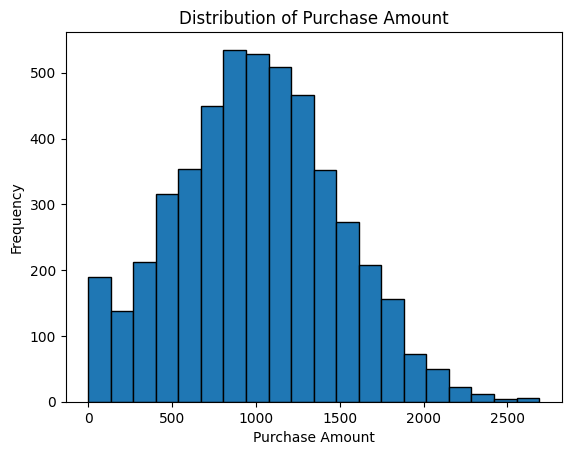

In [44]:
#8. Can we assume PurchaseAmount follows a normal distribution?
import matplotlib.pyplot as plt
plt.hist(df['PurchaseAmount'], bins=20,edgecolor = 'black')
plt.xlabel('Purchase Amount')
plt.ylabel('Frequency')
plt.title('Distribution of Purchase Amount')
plt.show()

In [46]:
#9. What insights can we gain by applying the Central Limit Theorem?

#Not sure it

In [54]:
#10.What is the 95% confidence interval for the average PurchaseAmount?

confidence_level = 0.95
sample_mean = df['PurchaseAmount'].mean()
sample_std = df['PurchaseAmount'].std()
n = len(df['PurchaseAmount'])

print(f"Sample Mean: {sample_mean:.2f}")
print(f"Sample Standard Deviation: {sample_std:.2f}")
print(f"Sample Size: {n}")

ci_lower, ci_upper = stats.t.interval(
    confidence=0.95,
    df=n-1,
    loc=sample_mean,
    scale=sample_std / np.sqrt(n)
)

print(f"95% Confidence Interval for Population Average PurchaseAmount = [${ci_lower:.2f}, ${ci_upper:.2f}]")



Sample Mean: 1003.95
Sample Standard Deviation: 482.11
Sample Size: 5000
95% Confidence Interval for Population Average PurchaseAmount = [$990.58, $1017.32]
